# Theoretical graph permutations

This notebook uses a small theoretical grid to show how the same node composition values behave under dispersed, clustered, and checkerboard placements. It does not load CBSA data. Metric formulas are imported directly from `pipeline/calculate_metrics.py`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

for candidate_root in [Path.cwd(), *Path.cwd().parents]:
    if (candidate_root / 'pipeline' / 'calculate_metrics.py').exists():
        project_root = candidate_root
        break
else:
    raise FileNotFoundError('Could not find pipeline/calculate_metrics.py')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pipeline import calculate_metrics as metrics

plt.rcParams.update({'figure.dpi': 130})

Each graph has the same 5-by-5 rook-adjacency structure and the same fixed multiset of 25 tract values. The tracts have varied X shares and varied total populations; only placement changes.

In [2]:
GRID_SHAPE = (5, 5)
RANDOM_SEED = 7
X_COL = 'x_pop'
Y_COL = 'y_pop'
TOT_COL = 'tot_pop'

rng = np.random.default_rng(RANDOM_SEED)
node_count = GRID_SHAPE[0] * GRID_SHAPE[1]
tract_shares = np.clip(np.sort(rng.beta(0.6, 0.9, node_count)), 0.02, 0.98)
tract_totals = np.rint(100 * np.exp(rng.uniform(0.0, np.log(30.0), node_count))).astype(int)
tract_x = np.rint(tract_shares * tract_totals).astype(int)
tract_y = tract_totals - tract_x

tract_values = pd.DataFrame({
    'tract_id': np.arange(node_count),
    'x_share': tract_x / tract_totals,
    X_COL: tract_x,
    Y_COL: tract_y,
    TOT_COL: tract_totals,
})

tract_values_display = tract_values.copy()
tract_values_display['x_share'] = tract_values_display['x_share'].round(3)
tract_values_display

,tract_id,x_share,x_pop,y_pop,tot_pop
0,0,0.020,50,2438,2488
1,1,0.020,43,2121,2164
2,2,0.020,14,680,694
3,3,0.024,4,160,164
4,4,0.036,7,185,192
5,5,0.040,93,2255,2348
6,6,0.113,74,580,654
7,7,0.135,25,160,185
8,8,0.201,407,1615,2022
9,9,0.245,217,670,887


In [3]:
rows = np.arange(node_count) // GRID_SHAPE[1]
cols = np.arange(node_count) % GRID_SHAPE[1]
tracts_by_x_share = tract_values.sort_values('x_share', ascending=False)['tract_id'].to_numpy()

clustered_order = np.empty(node_count, dtype=int)
clustered_order[np.argsort(rows + cols)] = tracts_by_x_share
dispersed_order = rng.permutation(node_count)
checkerboard_order = np.empty(node_count, dtype=int)
even_nodes = np.where((rows + cols) % 2 == 0)[0]
odd_nodes = np.where((rows + cols) % 2 == 1)[0]
checkerboard_order[even_nodes] = tracts_by_x_share[:len(even_nodes)]
checkerboard_order[odd_nodes] = tracts_by_x_share[len(even_nodes):]

placement_orders = {
    'Clustered': clustered_order,
    'Dispersed': dispersed_order,
    'Checkerboard': checkerboard_order,
}

pd.DataFrame({name: order.reshape(GRID_SHAPE).ravel() for name, order in placement_orders.items()})

,Clustered,Dispersed,Checkerboard
0,24,12,24
1,23,19,11
2,21,10,23
3,18,0,10
4,10,5,22
5,22,23,9
6,20,3,21
7,17,2,8
8,11,7,20
9,8,20,7


In [4]:
tract_lookup = tract_values.set_index('tract_id')


def make_theoretical_graph(placement_order):
    graph = nx.grid_2d_graph(*GRID_SHAPE)
    for node in graph.nodes:
        row, col = node
        grid_index = row * GRID_SHAPE[1] + col
        tract = tract_lookup.loc[int(placement_order[grid_index])]
        graph.nodes[node][X_COL] = int(tract[X_COL])
        graph.nodes[node][Y_COL] = int(tract[Y_COL])
        graph.nodes[node][TOT_COL] = int(tract[TOT_COL])
        graph.nodes[node]['x_share'] = graph.nodes[node][X_COL] / graph.nodes[node][TOT_COL]
        graph.nodes[node]['tract_id'] = int(tract.name)
    return graph


graphs = {
    name: make_theoretical_graph(order)
    for name, order in placement_orders.items()
}

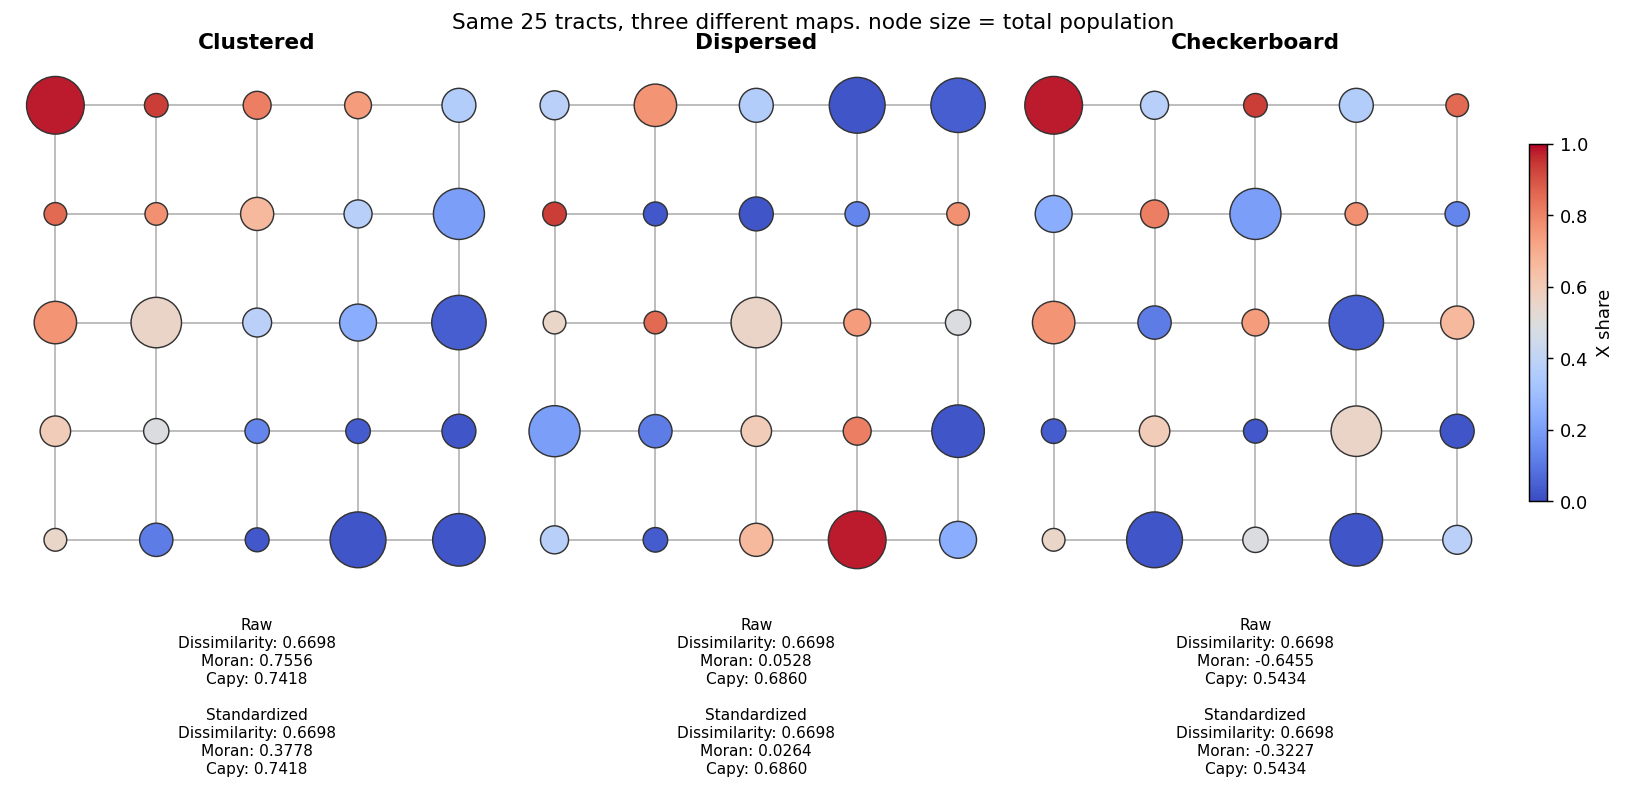

In [6]:
def draw_graphs(graphs):
    fig, axes = plt.subplots(1, len(graphs), figsize=(12.4, 5.8), constrained_layout=True)
    all_totals = [graph.nodes[node][TOT_COL] for graph in graphs.values() for node in graph.nodes]
    min_total = min(all_totals)
    max_total = max(all_totals)

    for ax, (name, graph) in zip(axes, graphs.items()):
        pos = {(row, col): (col, -row) for row, col in graph.nodes}
        x_shares = [graph.nodes[node]['x_share'] for node in graph.nodes]
        totals = [graph.nodes[node][TOT_COL] for node in graph.nodes]
        node_sizes = [120 + 900 * total / max_total for total in totals]

        nx.draw_networkx_edges(graph, pos=pos, ax=ax, width=1.0, edge_color='#b8b8b8')
        nx.draw_networkx_nodes(
            graph,
            pos=pos,
            ax=ax,
            node_color=x_shares,
            cmap='coolwarm',
            vmin=0,
            vmax=1,
            node_size=node_sizes,
            linewidths=0.8,
            edgecolors='#333333',
        )
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.set_axis_off()

        for cached_function in (metrics._angle_1, metrics._angle_2, metrics.property_sum):
            cached_function.cache_clear()
        raw_metric_values = {
            'Dissimilarity': metrics.dissimilarity(graph, X_COL, Y_COL),
            'Moran': metrics.moran(graph, X_COL, Y_COL),
            'Capy': metrics.half_edge(graph, X_COL, Y_COL, lam=1, func=metrics.angle_1),
        }
        standardized_metric_values = {
            'Dissimilarity': raw_metric_values['Dissimilarity'],
            'Moran': raw_metric_values['Moran'] / 2,
            'Capy': raw_metric_values['Capy'],
        }
        metric_text = (
            f"Raw\n"
            f"Dissimilarity: {raw_metric_values['Dissimilarity']:.4f}\n"
            f"Moran: {raw_metric_values['Moran']:.4f}\n"
            f"Capy: {raw_metric_values['Capy']:.4f}\n\n"
            f"Standardized\n"
            f"Dissimilarity: {standardized_metric_values['Dissimilarity']:.4f}\n"
            f"Moran: {standardized_metric_values['Moran']:.4f}\n"
            f"Capy: {standardized_metric_values['Capy']:.4f}"
        )
        ax.text(
            0.5,
            -0.06,
            metric_text,
            transform=ax.transAxes,
            ha='center',
            va='top',
            fontsize=8.5,
            linespacing=1.25,
            clip_on=False,
        )

    colorbar_source = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0, 1))
    colorbar_source.set_array([])
    fig.colorbar(colorbar_source, ax=axes, shrink=0.68, pad=0.02, label='X share')

    fig.suptitle('Same 25 tracts, three different maps. node size = total population', y=1.02, fontsize=12)
    return fig


draw_graphs(graphs);

`Capy` below is the pipeline's half-edge metric with `lambda=1` and `angle_1`, corresponding to the output column `half_edge_lam_1_angle_1` in `calculate_metrics.py`.

In [7]:
def score_graph(graph):
    for cached_function in (metrics._angle_1, metrics._angle_2, metrics.property_sum):
        cached_function.cache_clear()

    return {
        'Dissimilarity': metrics.dissimilarity(graph, X_COL, Y_COL),
        'Moran': metrics.moran(graph, X_COL, Y_COL),
        'Capy': metrics.half_edge(graph, X_COL, Y_COL, lam=1, func=metrics.angle_1),
    }


results = pd.DataFrame(
    [{'placement': name, **score_graph(graph)} for name, graph in graphs.items()]
).set_index('placement')

results.round(4)

,Dissimilarity,Moran,Capy
placement,,,
Clustered,0.6698,0.7556,0.7418
Dispersed,0.6698,0.0528,0.6860
Checkerboard,0.6698,-0.6455,0.5434


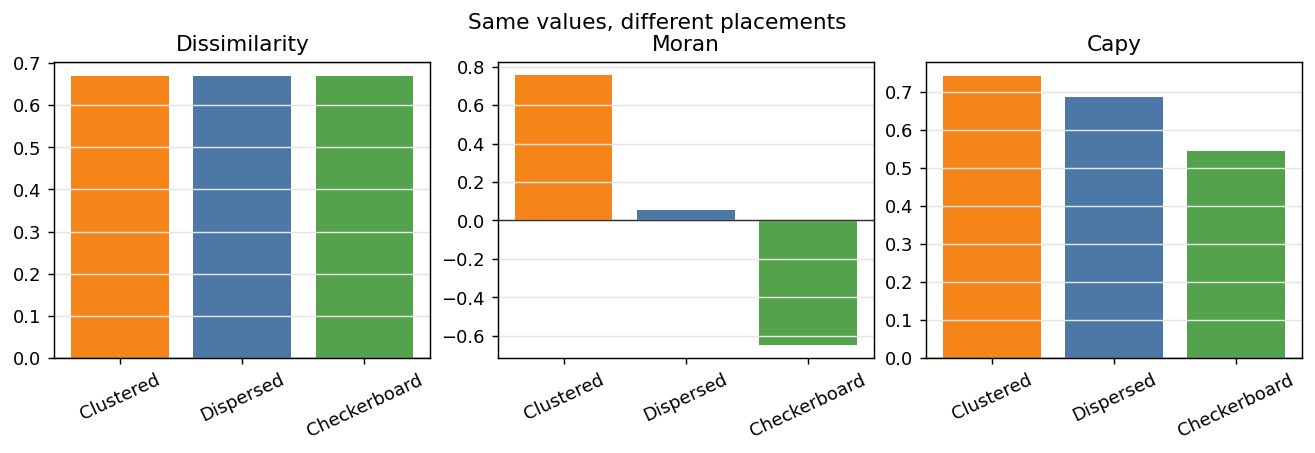

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
bar_colors = {
    'Dispersed': '#4c78a8',
    'Clustered': '#f58518',
    'Checkerboard': '#54a24b',
}

for ax, metric_name in zip(axes, results.columns):
    values = results[metric_name]
    ax.bar(values.index, values, color=[bar_colors[name] for name in values.index])
    ax.axhline(0, color='#333333', linewidth=0.8)
    ax.set_title(metric_name)
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', color='#e5e5e5', linewidth=0.8)

fig.suptitle('Same values, different placements', y=1.04);

Dissimilarity is unchanged across these permutations because it uses node compositions but not adjacency. Moran and Capy change because the same values are embedded in different neighboring relationships.